# 3. Análisis exploratorio de datos

## 3.0 Reserva del conjunto de prueba

El conjunto de prueba se reserva antes de tomar cualquier decisión basada en los datos. Los
umbrales, las curvas ajustadas, la imputación y la selección de variables se calculan
únicamente con el conjunto de entrenamiento.

Al tratarse de una serie de tiempo, la partición es cronológica y se deja un intervalo de
separación de treinta días entre ambos conjuntos, suficiente para cortar la dependencia de
corto plazo que documenta la sección 3.6.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import json, sys

sys.path.insert(0, ".")
from src.config import (SEED, DATOS_CRUDOS, DATOS_PROC, FIGURAS, ESTACION_OBJETIVO,
                        FECHA_CORTE_TEST, GAP_DIAS, HORIZONTE, TOLERANCIA,
                        EXCLUIR_MODELO, fijar_semillas, estilo_graficos)

fijar_semillas(SEED)
estilo_graficos()

df = pd.read_csv(DATOS_PROC / "caudales.csv", parse_dates=["fecha"])
ESTACIONES = [c for c in df.columns if c != "fecha"]
PREDICTORAS = [e for e in ESTACIONES if e != ESTACION_OBJETIVO and e not in EXCLUIR_MODELO]

print(f"{len(df):,} filas, {len(ESTACIONES)} estaciones")

31,475 filas, 7 estaciones


In [2]:
corte = pd.Timestamp(FECHA_CORTE_TEST)
inicio_test = corte + pd.Timedelta(days=GAP_DIAS)

train = df[df.fecha < corte].copy()
test = df[df.fecha >= inicio_test].copy()

print(f"Train: {train.fecha.min():%Y-%m-%d} a {train.fecha.max():%Y-%m-%d}   n = {len(train):,}")
print(f"Gap:   {GAP_DIAS} días")
print(f"Test:  {test.fecha.min():%Y-%m-%d} a {test.fecha.max():%Y-%m-%d}   n = {len(test):,}")

Train: 1940-07-23 a 2009-12-31   n = 25,364
Gap:   30 días
Test:  2010-01-31 a 2026-09-24   n = 6,081


## 3.1 Análisis de la variable objetivo

La variable objetivo se deriva del análisis magnitud-frecuencia. Antes de construirla es
necesario auditar la serie de transporte de sedimentos, puesto que de ella depende la curva
que pondera cada clase de caudal.

### 3.1.1 Auditoría de la serie de transporte

El campo `Parametro` de los archivos de transporte declara textualmente que el valor
*"se obtiene con la curva EQ_QS-QL"*. El dato publicado sería entonces el caudal
transformado mediante una curva de gasto sólido de la forma $Q_s = aQ^b$. La verificación
consiste en ajustar esa curva por bloques de cinco años: un coeficiente de determinación
igual a la unidad dentro de cada bloque indicaría una relación determinista.

In [3]:
def curva_gasto(q, qs):
    """Ajusta Qs = a * Q^b por regresion lineal en log-log."""
    m = (q > 0) & (qs > 0) & q.notna() & qs.notna()
    b, loga, r, _, _ = st.linregress(np.log10(q[m]), np.log10(qs[m]))
    return 10**loga, b, r**2, int(m.sum())

# Pares (Q, Qs) de la estacion objetivo, solo en el periodo de entrenamiento
q_cal = pd.read_csv(sorted(DATOS_CRUDOS.glob("*CALAMAR*Q_MEDIA*.csv"))[0],
                    encoding="utf-8-sig", parse_dates=["Fecha"])[["Fecha", "Q_MEDIA_D_m3_s"]]
s_cal = pd.read_csv(sorted(DATOS_CRUDOS.glob("*CALAMAR*TR_KT*.csv"))[0],
                    encoding="utf-8-sig", parse_dates=["Fecha"])[["Fecha", "TR_KT_D_QS_D_kt_dia"]]
par = q_cal.merge(s_cal, on="Fecha").dropna()
par.columns = ["fecha", "Q", "Qs"]
par = par[par.fecha < corte]

a, b, r2, n = curva_gasto(par.Q, par.Qs)
print(f"Ajuste global:  Qs = {a:.4g} * Q^{b:.4f}   R² = {r2:.4f}   n = {n:,}")

Ajuste global:  Qs = 0.0002021 * Q^1.6186   R² = 0.9410   n = 13,375


In [4]:
# El mismo ajuste, pero por bloques de cinco años
bloques = []
for ini, sub in par.groupby(par.fecha.dt.year // 5 * 5):
    if len(sub) < 150:
        continue
    a_i, b_i, r2_i, n_i = curva_gasto(sub.Q, sub.Qs)
    bloques.append({"bloque": f"{ini}-{ini+4}", "n": n_i, "a": a_i, "b": b_i, "R2": r2_i})

auditoria = pd.DataFrame(bloques)
print(auditoria.round(6).to_string(index=False))
print(f"\nBloques con R² > 0.999: {(auditoria.R2 > 0.999).sum()} de {len(auditoria)}")

   bloque    n        a        b       R2
1970-1974 1096 0.000851 1.439986 1.000000
1975-1979 1826 0.000851 1.439995 1.000000
1980-1984 1827 0.000851 1.439999 1.000000
1985-1989 1826 0.000013 1.940139 0.960788
1990-1994 1826 0.000007 2.018998 1.000000
1995-1999 1446 0.000007 2.016280 0.999882
2000-2004 1824 0.000625 1.488830 0.999739
2005-2009 1704 0.000569 1.499333 0.997645

Bloques con R² > 0.999: 6 de 8


In [5]:
# Dos verificaciones adicionales
from statsmodels.tsa.stattools import acf

residuo = np.log10(par.Qs) - np.log10(a * par.Q**b)
ac = acf(residuo.values, nlags=30, fft=True)
print(f"ACF del residuo:  lag1 = {ac[1]:.4f}   lag7 = {ac[7]:.4f}   lag30 = {ac[30]:.4f}")
print()

# Histeresis: un transporte medido da exponentes distintos al subir y al bajar
p = par.sort_values("fecha").copy()
p["dQ"] = p.Q.diff()
for rama, cond in [("ascenso", p.dQ > 0), ("descenso", p.dQ < 0)]:
    a_r, b_r, _, n_r = curva_gasto(p.loc[cond, "Q"], p.loc[cond, "Qs"])
    print(f"rama de {rama:9} n = {n_r:>6,}   b = {b_r:.4f}   a = {a_r:.4g}")

ACF del residuo:  lag1 = 0.9990   lag7 = 0.9856   lag30 = 0.8873

rama de ascenso   n =  6,706   b = 1.6185   a = 0.0002028
rama de descenso  n =  5,742   b = 1.6152   a = 0.0002075


Dentro de cada bloque quinquenal la relación resulta exacta. El coeficiente global inferior
a la unidad proviene de que el IDEAM cambió la ecuación varias veces a lo largo del
registro. La autocorrelación de primer orden del residuo, próxima a uno, descarta que se
trate de ruido de medición e indica un desfase sistemático entre curvas sucesivas. Las
ramas de ascenso y descenso del hidrograma arrojan además el mismo exponente, de modo que
no existe histéresis, fenómeno que todo proceso de transporte medido en campo presenta.

De esta constatación se derivan varias decisiones de diseño. Ajustar una curva de gasto
sólido propia carecería de sentido, porque el procedimiento recuperaría la ecuación que el
propio IDEAM aplicó. El transporte queda excluido tanto del conjunto de predictores como de
la variable objetivo, ya que su dependencia determinista del caudal introduciría una fuga
completa. La curva oficial se emplea únicamente para localizar la descarga efectiva dentro
del análisis magnitud-frecuencia. El cambio de ecuación entre periodos vuelve además
inhomogénea la serie publicada, que por ello no admite análisis de tendencia sedimentaria
de largo plazo.

### 3.1.2 Cálculo de la descarga efectiva

El procedimiento discretiza el caudal en clases, pondera cada clase por la magnitud del
transporte asociado y localiza el máximo del producto (Wolman y Miller, 1960; Andrews,
1980). Se aplica solo al conjunto de entrenamiento.

In [6]:
def descarga_efectiva(caudal, a, b, n_clases=25):
    """Analisis magnitud-frecuencia. Devuelve Q_ef y la tabla por clases."""
    x = caudal.dropna()
    x = x[x > 0]
    bordes = np.logspace(np.log10(x.min()), np.log10(x.max()), n_clases + 1)
    frec, _ = np.histogram(x, bins=bordes)
    centros = np.sqrt(bordes[:-1] * bordes[1:])
    carga = frec * (a * centros**b)
    t = pd.DataFrame({"q_inf": bordes[:-1], "q_sup": bordes[1:], "q_centro": centros,
                      "dias": frec, "frec_rel": frec / frec.sum(),
                      "carga_rel": carga / carga.sum()})
    i = t.carga_rel.idxmax()
    return t.loc[i, "q_centro"], (t.loc[i, "q_inf"], t.loc[i, "q_sup"]), t

# Curva vigente: la del ultimo bloque de la auditoria
A_OF, B_OF = auditoria.iloc[-1][["a", "b"]]
Q_EF, CLASE_EF, tabla_ef = descarga_efectiva(train[ESTACION_OBJETIVO], A_OF, B_OF)

qm = train[ESTACION_OBJETIVO].mean()
print(f"Curva utilizada:    Qs = {A_OF:.4g} * Q^{B_OF:.4f}")
print(f"Descarga efectiva:  {Q_EF:,.0f} m³/s")
print(f"Clase modal:        [{CLASE_EF[0]:,.0f} - {CLASE_EF[1]:,.0f}] m³/s")
print(f"Caudal medio:       {qm:,.0f} m³/s    Q_ef/Q_medio = {Q_EF/qm:.2f}")
print(f"Excedencia:         {100*(train[ESTACION_OBJETIVO] >= Q_EF).mean():.1f}% del tiempo")
print()
print("Robustez frente a la curva elegida:")
for _, r in auditoria.iterrows():
    qe, _, _ = descarga_efectiva(train[ESTACION_OBJETIVO], r.a, r.b)
    print(f"  {r.bloque} (b = {r.b:.3f})  ->  Q_ef = {qe:,.0f} m³/s")

Curva utilizada:    Qs = 0.0005689 * Q^1.4993
Descarga efectiva:  9,954 m³/s
Clase modal:        [9,486 - 10,446] m³/s
Caudal medio:       7,189 m³/s    Q_ef/Q_medio = 1.38
Excedencia:         15.4% del tiempo

Robustez frente a la curva elegida:
  1970-1974 (b = 1.440)  ->  Q_ef = 9,954 m³/s
  1975-1979 (b = 1.440)  ->  Q_ef = 9,954 m³/s
  1980-1984 (b = 1.440)  ->  Q_ef = 9,954 m³/s
  1985-1989 (b = 1.940)  ->  Q_ef = 9,954 m³/s
  1990-1994 (b = 2.019)  ->  Q_ef = 9,954 m³/s
  1995-1999 (b = 2.016)  ->  Q_ef = 9,954 m³/s
  2000-2004 (b = 1.489)  ->  Q_ef = 9,954 m³/s
  2005-2009 (b = 1.499)  ->  Q_ef = 9,954 m³/s


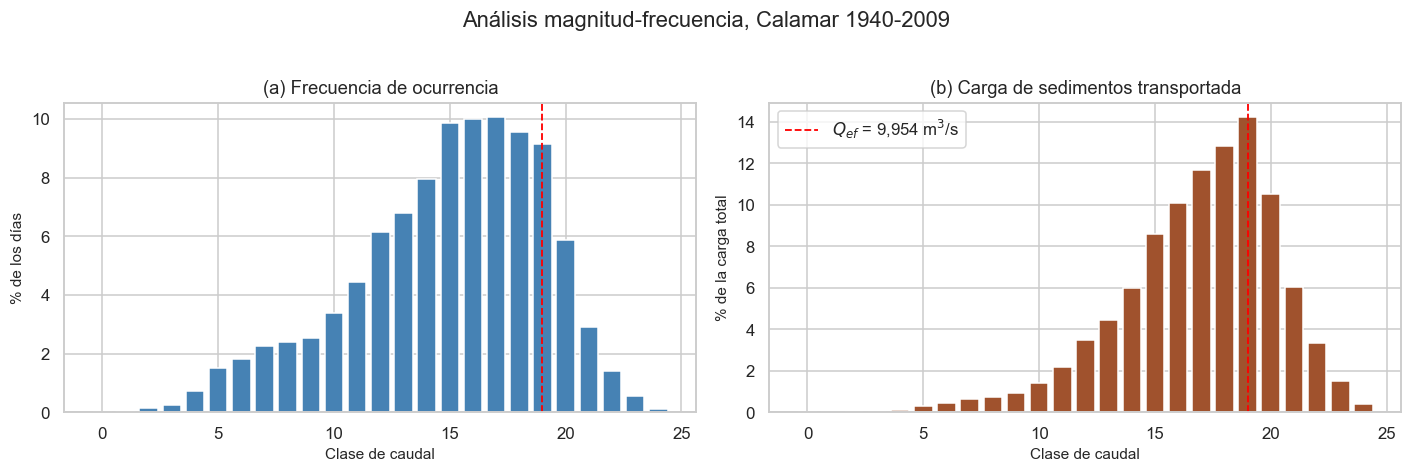

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
i_max = tabla_ef.carga_rel.idxmax()

ax[0].bar(range(len(tabla_ef)), 100 * tabla_ef.frec_rel, color="steelblue")
ax[0].axvline(i_max, color="red", ls="--", lw=1.2)
ax[0].set(title="(a) Frecuencia de ocurrencia", xlabel="Clase de caudal", ylabel="% de los días")

ax[1].bar(range(len(tabla_ef)), 100 * tabla_ef.carga_rel, color="sienna")
ax[1].axvline(i_max, color="red", ls="--", lw=1.2, label=f"$Q_{{ef}}$ = {Q_EF:,.0f} m$^3$/s")
ax[1].set(title="(b) Carga de sedimentos transportada", xlabel="Clase de caudal",
          ylabel="% de la carga total")
ax[1].legend()

fig.suptitle("Análisis magnitud-frecuencia, Calamar 1940-2009", y=1.02)
plt.tight_layout()
plt.savefig(FIGURAS / "magnitud_frecuencia.png", dpi=150)
plt.show()

El panel izquierdo decrece, puesto que los caudales grandes son raros. El panel derecho,
producto de esa frecuencia por la magnitud del transporte, presenta un máximo interior: ni
las crecidas extremas ni los caudales bajos dominan el balance sedimentario de largo plazo.

El valor obtenido supera al caudal medio y queda muy por debajo del máximo registrado, en
línea con lo que predice el modelo de magnitud y frecuencia. Las cuatro curvas históricas
del IDEAM, cuyos exponentes varían entre 1,44 y 2,02, conducen a la misma clase modal, lo
que indica que la posición del máximo depende de la distribución de frecuencias más que de
la escala de la curva.

### 3.1.3 Construcción de la variable objetivo

$$y_{t} = \begin{cases} 1 & \text{si } Q_{t+h} \in [(1-\tau)\,Q_{ef},\ (1+\tau)\,Q_{ef}] \\ 0 & \text{en otro caso}\end{cases}$$

con horizonte $h = 15$ días y tolerancia $\tau = 0{,}15$. El objetivo se sitúa en $t+h$
mientras que todos los predictores usan información hasta $t$, de modo que la construcción
excluye por diseño la fuga temporal.

In [8]:
LIM = (Q_EF * (1 - TOLERANCIA), Q_EF * (1 + TOLERANCIA))
df["y"] = df[ESTACION_OBJETIVO].between(*LIM).astype(float).shift(-HORIZONTE)

print(f"Banda: [{LIM[0]:,.0f} - {LIM[1]:,.0f}] m³/s")
print()
print("Prevalencia según la definición del objetivo (en entrenamiento):")
qtr = train[ESTACION_OBJETIVO]
print(f"  clase modal exacta      [{CLASE_EF[0]:>7,.0f} - {CLASE_EF[1]:>8,.0f}]   {qtr.between(*CLASE_EF).mean():>7.2%}")
for tol in (0.10, 0.15, 0.25, 0.35):
    lo, hi = Q_EF * (1 - tol), Q_EF * (1 + tol)
    print(f"  banda ±{tol:.0%}{'':14}[{lo:>7,.0f} - {hi:>8,.0f}]   {qtr.between(lo, hi).mean():>7.2%}")
print(f"  excedencia Q >= Q_ef    [{Q_EF:>7,.0f} -      inf]   {(qtr >= Q_EF).mean():>7.2%}")
print()
ytr = df.loc[df.fecha < corte, "y"]
vc = ytr.value_counts().sort_index()
print("Distribución del objetivo en entrenamiento:")
for k, v in vc.items():
    print(f"  clase {int(k)}: {v:>7,}  ({v/vc.sum():6.2%})")
print(f"  desbalance: {vc.max()/vc.min():.2f} : 1")

Banda: [8,461 - 11,448] m³/s

Prevalencia según la definición del objetivo (en entrenamiento):
  clase modal exacta      [  9,486 -   10,446]     9.00%
  banda ±10%              [  8,959 -   10,950]    17.56%
  banda ±15%              [  8,461 -   11,448]    25.67%
  banda ±25%              [  7,466 -   12,443]    41.33%
  banda ±35%              [  6,470 -   13,439]    57.05%
  excedencia Q >= Q_ef    [  9,954 -      inf]    15.40%

Distribución del objetivo en entrenamiento:
  clase 0:  18,853  (74.33%)
  clase 1:   6,511  (25.67%)
  desbalance: 2.90 : 1


La excedencia convierte el problema en predecir aguas altas y pierde la especificidad del
concepto, que se refiere a una banda de caudales alrededor del máximo de transporte. La
clase modal exacta tiene una prevalencia demasiado baja. La banda de ±15 % conserva el
significado hidrológico con un desbalance manejable.

Con esta prevalencia, un clasificador que prediga siempre la clase mayoritaria alcanzaría
un acierto elevado sin valor predictivo. La evaluación prioriza en consecuencia la
precisión, la exhaustividad y el área bajo la curva precisión-exhaustividad de la clase
positiva.

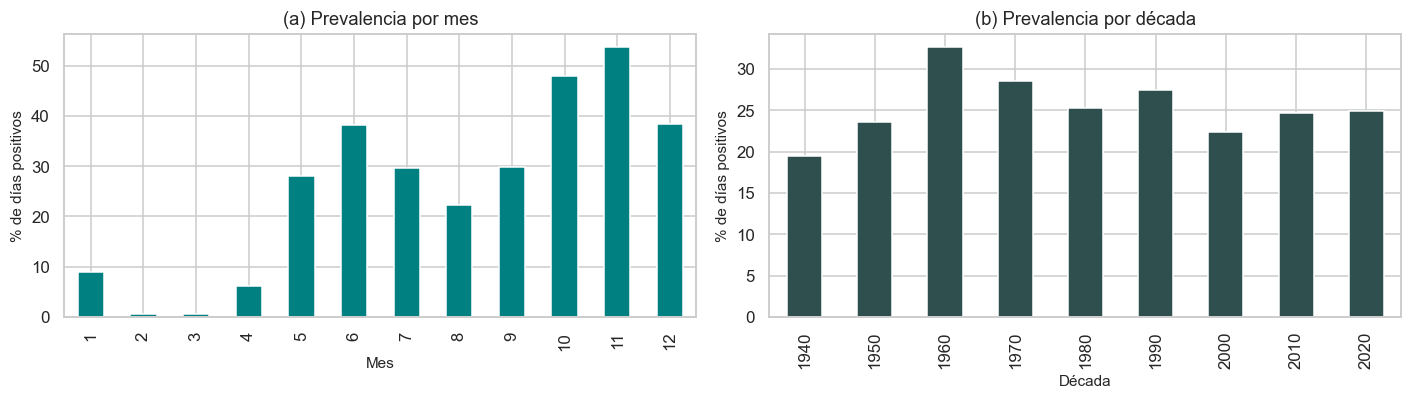

In [9]:
d = df.dropna(subset=["y"]).copy()
d["mes"] = d.fecha.dt.month
d["decada"] = d.fecha.dt.year // 10 * 10

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
d.groupby("mes").y.mean().mul(100).plot(kind="bar", ax=ax[0], color="teal")
ax[0].set(title="(a) Prevalencia por mes", xlabel="Mes", ylabel="% de días positivos")
d.groupby("decada").y.mean().mul(100).plot(kind="bar", ax=ax[1], color="darkslategray")
ax[1].set(title="(b) Prevalencia por década", xlabel="Década", ylabel="% de días positivos")
plt.tight_layout()
plt.savefig(FIGURAS / "objetivo_tiempo.png", dpi=150)
plt.show()

## 3.2 Análisis unidimensional

In [10]:
filas = []
for c in ESTACIONES:
    s = train[c].dropna()
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    filas.append({"estacion": c, "n": len(s), "faltante_%": 100 * train[c].isna().mean(),
                  "media": s.mean(), "mediana": s.median(), "desv": s.std(),
                  "p01": s.quantile(.01), "p99": s.quantile(.99),
                  "min": s.min(), "max": s.max(),
                  "asimetria": s.skew(), "curtosis": s.kurtosis(),
                  "outliers_IQR_%": 100 * ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean()})

pd.DataFrame(filas).set_index("estacion").round(2)

,n,faltante_%,media,mediana,desv,p01,p99,min,max,asimetria,curtosis,outliers_IQR_%
estacion,,,,,,,,,,,,
arrancaplumas,23931,5.65,1300.12,1167.0,608.44,439.00,3234.40,212.0,7215.0,1.24,1.99,3.60
calamar,24925,1.73,7189.30,7078.0,2586.28,2421.00,13553.04,1520.0,16913.0,0.26,-0.31,0.37
coyongal,11278,55.54,4926.37,4977.0,1477.01,1823.08,7964.00,874.8,8648.0,-0.13,-0.62,0.00
el_banco,13454,46.96,4194.18,4020.0,1523.10,1383.06,8503.00,911.9,9681.0,0.59,0.37,1.73
pto_salgar,22370,11.80,1598.26,1440.0,769.24,493.00,3969.89,320.0,5880.0,1.12,1.43,2.91
san_roque,13188,48.01,521.17,461.9,306.65,24.00,1332.13,7.0,1559.0,0.68,-0.02,0.83
tres_cruces,11386,55.11,2544.38,2502.0,938.17,743.00,4885.00,581.0,5244.0,0.21,-0.44,0.00


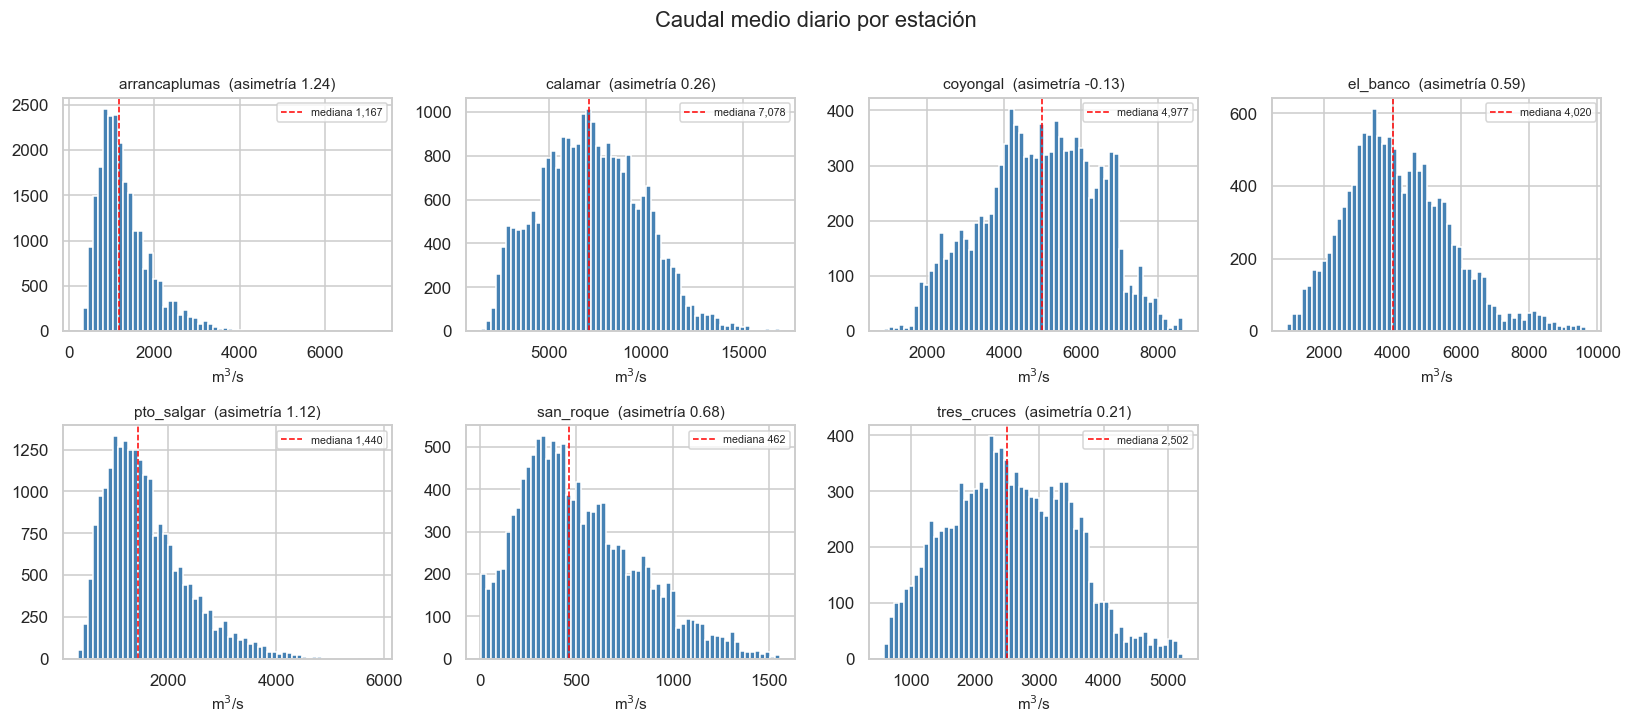

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, e in zip(axes.ravel(), ESTACIONES):
    s = train[e].dropna()
    ax.hist(s, bins=60, color="steelblue")
    ax.axvline(s.median(), color="red", ls="--", lw=1, label=f"mediana {s.median():,.0f}")
    ax.set_title(f"{e}  (asimetría {s.skew():.2f})", fontsize=10)
    ax.set_xlabel("m$^3$/s")
    ax.legend(fontsize=7)
axes.ravel()[-1].axis("off")
fig.suptitle("Caudal medio diario por estación", y=1.01)
plt.tight_layout()
plt.savefig(FIGURAS / "histogramas.png", dpi=150)
plt.show()

In [12]:
# Pruebas de normalidad. Con n de este orden rechazan casi siempre,
# asi que la decision se apoya en la asimetria y en los histogramas.
filas = []
for e in ESTACIONES:
    s = train[e].dropna()
    m = s.sample(min(5000, len(s)), random_state=SEED)
    filas.append({"estacion": e, "shapiro_p": st.shapiro(m)[1],
                  "jarque_bera_p": st.jarque_bera(s)[1], "asimetria": s.skew()})

pd.DataFrame(filas).round(4)

,estacion,shapiro_p,jarque_bera_p,asimetria
0,arrancaplumas,0.0,0.0,1.2441
1,calamar,0.0,0.0,0.2606
2,coyongal,0.0,0.0,-0.1271
3,el_banco,0.0,0.0,0.5908
4,pto_salgar,0.0,0.0,1.1213
5,san_roque,0.0,0.0,0.6833
6,tres_cruces,0.0,0.0,0.2075


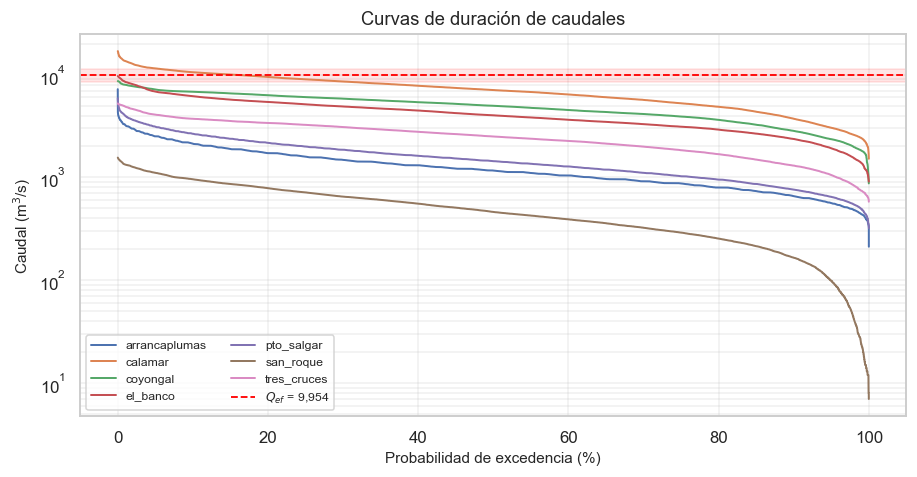

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for e in ESTACIONES:
    s = np.sort(train[e].dropna().values)[::-1]
    p = np.arange(1, len(s) + 1) / (len(s) + 1)
    ax.plot(100 * p, s, lw=1.3, label=e)

ax.axhline(Q_EF, color="red", ls="--", lw=1.2, label=f"$Q_{{ef}}$ = {Q_EF:,.0f}")
ax.axhspan(*LIM, color="red", alpha=0.10)
ax.set(yscale="log", xlabel="Probabilidad de excedencia (%)", ylabel="Caudal (m$^3$/s)",
       title="Curvas de duración de caudales")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which="both", alpha=.3)
plt.tight_layout()
plt.savefig(FIGURAS / "curva_duracion.png", dpi=150)
plt.show()

Los caudales medios crecen de forma monótona aguas abajo, desde los brazos de la depresión
momposina hasta Calamar, puesto que cada estación incorpora la escorrentía de una cuenca
mayor.

La estación objetivo presenta una distribución casi simétrica, poco habitual en registros
de caudal. Su posición en el bajo Magdalena explica ese comportamiento, dado que la cuenca
integra y amortigua los picos de crecida generados aguas arriba. La transformación
logarítmica o de Box-Cox queda descartada por esa razón, decisión que se registra en la
sección 3.8.

Las estaciones de aguas arriba resultan más asimétricas, lo que resulta coherente con
cuencas menores y respuesta más torrencial. El comportamiento estadístico varía por tanto a
lo largo del cauce.

Las proporciones de valores extremos detectadas por el rango intercuartílico son bajas y no
se recortan, según el criterio establecido en la sección 2.6.3. La banda de descarga
efectiva se sitúa en la parte alta-intermedia de la curva de duración de Calamar, lo que
confirma gráficamente que dista de ser un valor extremo.

## 3.3 Análisis bidimensional

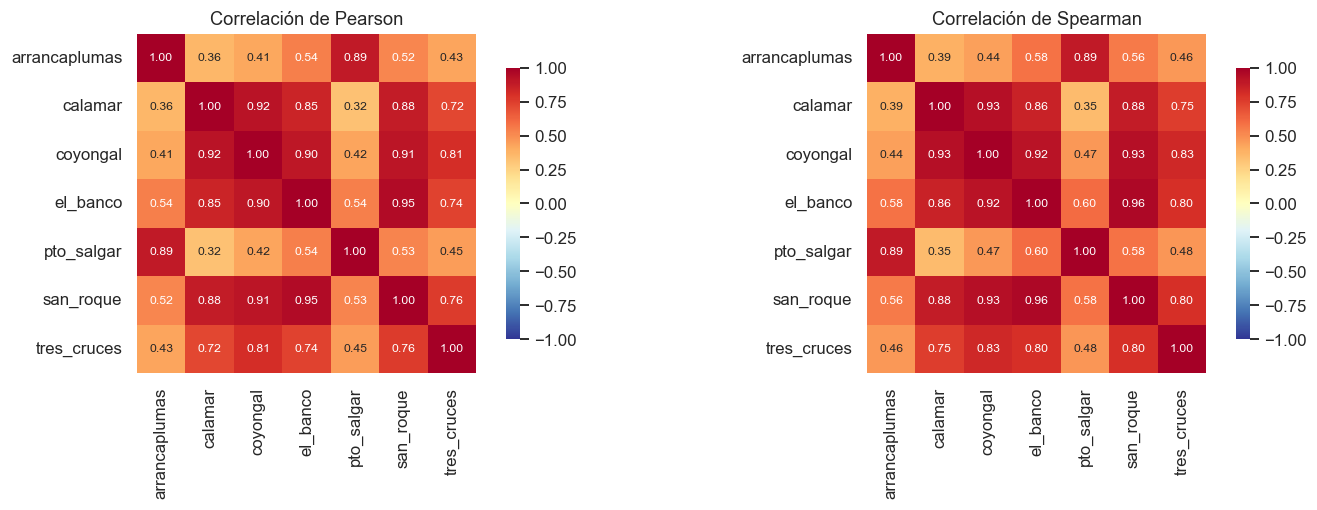

Correlación con la estación objetivo:
coyongal         0.920
san_roque        0.878
el_banco         0.850
tres_cruces      0.723
arrancaplumas    0.359
pto_salgar       0.324


In [14]:
corr_p = train[ESTACIONES].corr()
corr_s = train[ESTACIONES].corr(method="spearman")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
for a_, (m, t) in zip(ax, [(corr_p, "Pearson"), (corr_s, "Spearman")]):
    sns.heatmap(m, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
                square=True, ax=a_, cbar_kws={"shrink": .8}, annot_kws={"size": 8})
    a_.set_title(f"Correlación de {t}")
plt.tight_layout()
plt.savefig(FIGURAS / "correlaciones.png", dpi=150)
plt.show()

print("Correlación con la estación objetivo:")
print(corr_p[ESTACION_OBJETIVO].drop(ESTACION_OBJETIVO).sort_values(ascending=False).round(3).to_string())

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

sub = train.dropna(subset=ESTACIONES)
X = sm.add_constant(sub[ESTACIONES])
vif = pd.DataFrame({"estacion": X.columns,
                    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
vif = vif[vif.estacion != "const"].sort_values("VIF", ascending=False)

print(f"Periodo con todas las estaciones: {len(sub):,} días")
print(vif.round(2).to_string(index=False))

Periodo con todas las estaciones: 9,385 días
     estacion   VIF
    san_roque 14.40
     coyongal 14.33
     el_banco 12.23
   pto_salgar 11.00
arrancaplumas 10.99
      calamar  7.91
  tres_cruces  2.95


In [16]:
from statsmodels.stats.multitest import multipletests
from sklearn.feature_selection import mutual_info_classif

dtr = df[df.fecha < corte].dropna(subset=["y"])

filas = []
for e in ESTACIONES:
    s = dtr[[e, "y"]].dropna()
    a_, b_ = s.loc[s.y == 1, e], s.loc[s.y == 0, e]
    u, pv = st.mannwhitneyu(a_, b_)
    filas.append({"estacion": e, "mediana_y1": a_.median(), "mediana_y0": b_.median(),
                  "p_valor": pv, "efecto_A": u / (len(a_) * len(b_)),
                  "cohen_d": (a_.mean() - b_.mean()) / np.sqrt((a_.var() + b_.var()) / 2)})

aso = pd.DataFrame(filas)
aso["p_holm"] = multipletests(aso.p_valor, method="holm")[1]

mi = dtr[ESTACIONES + ["y"]].dropna()
aso["info_mutua"] = mutual_info_classif(mi[ESTACIONES], mi.y, random_state=SEED)

print("Con n de este orden casi toda diferencia resulta significativa, por lo que")
print("se reporta el tamaño de efecto junto al p-valor, con corrección de Holm.")
aso.round(4)

Con n de este orden casi toda diferencia resulta significativa, por lo que
se reporta el tamaño de efecto junto al p-valor, con corrección de Holm.


,estacion,mediana_y1,mediana_y0,p_valor,efecto_A,cohen_d,p_holm,info_mutua
0,arrancaplumas,1399.00,1085.00,0.0,0.6665,0.5138,0.0,0.0305
1,calamar,9470.00,6201.00,0.0,0.8892,1.6403,0.0,0.3031
2,coyongal,6268.00,4384.00,0.0,0.8885,1.7200,0.0,0.3230
3,el_banco,5361.00,3562.00,0.0,0.8492,1.2799,0.0,0.2311
4,pto_salgar,1694.00,1334.00,0.0,0.6565,0.5024,0.0,0.0437
5,san_roque,754.95,375.45,0.0,0.8425,1.2661,0.0,0.2606
6,tres_cruces,3308.00,2237.00,0.0,0.8305,1.3289,0.0,0.1884


### 3.3.1 La multicolinealidad como resultado físico

Los factores de inflación de varianza elevados reflejan que todas las estaciones miden el
mismo sistema físico en puntos distintos. El agua registrada aguas arriba es, días después,
la que se registra en Calamar.

La matriz de correlación revela una estructura en dos bloques. Las estaciones del alto
Magdalena, Arrancaplumas y Puerto Salgar, correlacionan fuertemente entre sí y débilmente
con la estación objetivo, mientras que las del bajo Magdalena, Coyongal, El Banco y San
Roque, lo hacen con Calamar. Entre ambos grupos ingresan los aportes del Cauca, el Cesar y
el San Jorge, y se interpone la depresión momposina, que amortigua y redistribuye la onda
de crecida (Restrepo et al., 2006). El alto Magdalena resulta así poco informativo sobre el
comportamiento del bajo Magdalena.

Con predictores fuertemente colineales, los coeficientes individuales de la regresión
logística se vuelven inestables y difíciles de interpretar, aunque la capacidad predictiva
agregada no tiene por qué degradarse. Esta circunstancia motiva las técnicas de
regularización y la reducción de dimensionalidad que explora la sección siguiente.

## 3.4 Análisis multivariado

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import MinCovDet

Xs = StandardScaler().fit_transform(sub[ESTACIONES])
pca = PCA().fit(Xs)

varianza = pd.DataFrame({
    "componente": [f"PC{i+1}" for i in range(len(ESTACIONES))],
    "varianza_explicada": pca.explained_variance_ratio_,
    "acumulada": pca.explained_variance_ratio_.cumsum()})

n90 = int((varianza.acumulada < 0.90).sum() + 1)
print(varianza.round(4).to_string(index=False))
print(f"\nComponentes para el 90% de la varianza: {n90} de {len(ESTACIONES)}")

pesos = pd.DataFrame(pca.components_[:3].T, index=ESTACIONES, columns=["PC1", "PC2", "PC3"])
print("\nPesos de las tres primeras componentes:")
print(pesos.round(3).to_string())

componente  varianza_explicada  acumulada
       PC1              0.7071     0.7071
       PC2              0.2002     0.9073
       PC3              0.0483     0.9555
       PC4              0.0237     0.9792
       PC5              0.0085     0.9878
       PC6              0.0067     0.9945
       PC7              0.0055     1.0000

Componentes para el 90% de la varianza: 2 de 7

Pesos de las tres primeras componentes:
                 PC1    PC2    PC3
arrancaplumas  0.286  0.638  0.027
calamar        0.393 -0.305  0.196
coyongal       0.422 -0.224  0.063
el_banco       0.423 -0.101  0.313
pto_salgar     0.287  0.635 -0.004
san_roque      0.428 -0.133  0.223
tres_cruces    0.376 -0.134 -0.900


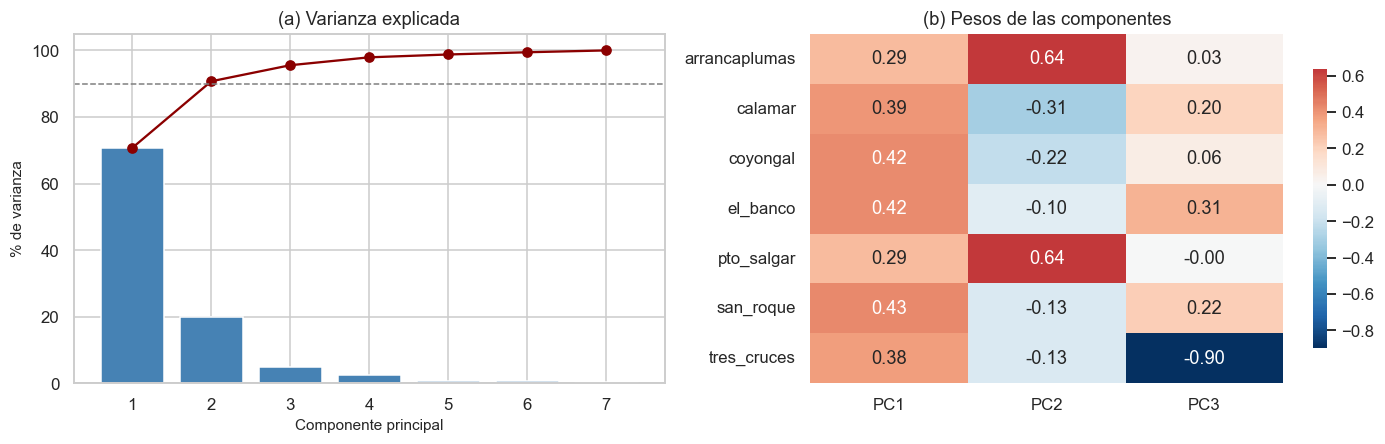

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].bar(range(1, len(ESTACIONES) + 1), 100 * pca.explained_variance_ratio_, color="steelblue")
ax[0].plot(range(1, len(ESTACIONES) + 1), 100 * varianza.acumulada, "o-", color="darkred")
ax[0].axhline(90, ls="--", color="gray", lw=1)
ax[0].set(xlabel="Componente principal", ylabel="% de varianza", title="(a) Varianza explicada")

sns.heatmap(pesos, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax[1], cbar_kws={"shrink": .8})
ax[1].set_title("(b) Pesos de las componentes")
plt.tight_layout()
plt.savefig(FIGURAS / "pca.png", dpi=150)
plt.show()

In [19]:
# Dias en que las estaciones se comportan de forma incoherente entre si
mcd = MinCovDet(random_state=SEED).fit(sub[ESTACIONES])
d2 = mcd.mahalanobis(sub[ESTACIONES])
umbral = st.chi2.ppf(0.999, df=len(ESTACIONES))

atipicos = sub.loc[d2 > umbral, ["fecha"] + ESTACIONES].copy()
atipicos["mahalanobis"] = d2[d2 > umbral]

print(f"Umbral chi² (p = 0.001, gl = {len(ESTACIONES)}): {umbral:.1f}")
print(f"Días atípicos: {len(atipicos):,} de {len(sub):,} ({len(atipicos)/len(sub):.2%})")
atipicos.nlargest(8, "mahalanobis").round(0)

Umbral chi² (p = 0.001, gl = 7): 24.3
Días atípicos: 1,058 de 9,385 (11.27%)


,fecha,arrancaplumas,calamar,coyongal,el_banco,pto_salgar,san_roque,tres_cruces,mahalanobis
15171,1982-02-04,951.0,6080.0,3845.0,3052.0,3464.0,237.0,1795.0,365.0
15170,1982-02-03,1075.0,6155.0,3805.0,2950.0,3403.0,228.0,1782.0,314.0
15176,1982-02-09,1198.0,5795.0,3892.0,3096.0,3335.0,274.0,1860.0,259.0
21447,1999-04-12,3580.0,8346.0,5708.0,4734.0,5434.0,766.0,4041.0,227.0
24782,2008-05-29,3506.0,8589.0,5993.0,5156.0,5322.0,798.0,4885.0,217.0
21403,1999-02-27,3856.0,7445.0,5486.0,4499.0,5605.0,686.0,4107.0,216.0
21650,1999-11-01,3765.0,12672.0,6879.0,5969.0,5377.0,1138.0,4815.0,212.0
15175,1982-02-08,1681.0,5825.0,3859.0,3026.0,3579.0,249.0,1893.0,209.0


La primera componente principal concentra la mayor parte de la varianza con pesos del mismo
signo en todas las estaciones, de modo que representa el estado hidrológico general de la
cuenca. La segunda presenta pesos de signo contrario entre el alto y el bajo Magdalena y
captura el contraste longitudinal identificado en la sección anterior. La dimensionalidad
efectiva queda muy por debajo del número de estaciones, lo que cuantifica la redundancia
del sistema.

La distancia de Mahalanobis calculada con el estimador de covarianza mínima robusta
identifica días en que las estaciones se comportan de forma mutuamente incoherente, por
ejemplo una crecida marcada aguas arriba sin respuesta aguas abajo. El criterio resulta
preferible al rango intercuartílico univariado para detectar errores de medición, puesto
que las crecidas generalizadas afectan a todas las estaciones a la vez y no quedan
penalizadas (Rousseeuw y Van Driessen, 1999).

## 3.5 Auditoría de fuga de datos

Cada variable debe estar disponible en el momento de la predicción.

| Variable | Disponibilidad en $t$ | Justificación |
|---|---|---|
| Caudal de Calamar en $t$ y rezagos | disponible | se mide y se publica el mismo día |
| Caudal de estaciones aguas arriba y rezagos | disponible | se mide y se publica el mismo día |
| Componentes de calendario | disponible | son deterministas |
| $\lvert Q_t - Q_{ef}\rvert$ | disponible | se calcula con $Q_t$ y una constante estimada en entrenamiento |
| Caudal en $t+15$ | no disponible | sobre él se construye la variable objetivo |
| Transporte de sedimentos | no disponible | depende de forma determinista del caudal (3.1.1) |

Los controles aplicados comprueban que ninguna variable derive del objetivo, calculan el
área bajo la curva ROC de cada predictor por separado y verifican la ausencia de
solapamiento entre particiones.

In [20]:
from sklearn.metrics import roc_auc_score

filas = []
for e in ESTACIONES:
    s = dtr[[e, "y"]].dropna()
    auc = roc_auc_score(s.y, s[e])
    filas.append({"estacion": e, "AUC_univariado": max(auc, 1 - auc)})

fuga = pd.DataFrame(filas).sort_values("AUC_univariado", ascending=False)
print(fuga.round(4).to_string(index=False))
print(f"\nVariables con AUC > 0.95: {(fuga.AUC_univariado > 0.95).sum()}")
print(f"Fechas comunes entre train y test: {len(set(train.fecha) & set(test.fecha))}")

     estacion  AUC_univariado
      calamar          0.8892
     coyongal          0.8885
     el_banco          0.8492
    san_roque          0.8425
  tres_cruces          0.8305
arrancaplumas          0.6665
   pto_salgar          0.6565

Variables con AUC > 0.95: 0
Fechas comunes entre train y test: 0


## 3.6 Componente temporal

In [21]:
f = train.fecha
print(f"Cobertura: {f.min():%Y-%m-%d} a {f.max():%Y-%m-%d}  ({(f.max()-f.min()).days/365.25:.1f} años)")
print(f"Frecuencia: diaria regular    Fechas duplicadas: {f.duplicated().sum()}")
print()

s = train[ESTACION_OBJETIVO]
sin_dato = train.loc[s.isna(), "fecha"]
print(f"Días sin dato en la estación objetivo: {len(sin_dato):,} ({s.isna().mean():.2%})")

if len(sin_dato):
    g = sin_dato.diff().dt.days.ne(1).cumsum()
    huecos = sin_dato.groupby(g).agg(["size", "min", "max"])
    huecos.columns = ["dias", "desde", "hasta"]
    huecos = huecos.sort_values("dias", ascending=False)
    print(f"Número de huecos: {len(huecos)}")
    print("\nLos ocho más largos:")
    for _, r in huecos.head(8).iterrows():
        print(f"  {r.dias:>4} días   {r.desde:%Y-%m-%d} a {r.hasta:%Y-%m-%d}")

Cobertura: 1940-07-23 a 2009-12-31  (69.4 años)
Frecuencia: diaria regular    Fechas duplicadas: 0

Días sin dato en la estación objetivo: 439 (1.73%)
Número de huecos: 13

Los ocho más largos:
    89 días   1945-02-01 a 1945-04-30
    81 días   1944-01-25 a 1944-04-14
    61 días   1970-11-01 a 1970-12-31
    48 días   1956-11-14 a 1956-12-31
    42 días   1955-11-13 a 1955-12-24
    33 días   1948-02-28 a 1948-03-31
    23 días   1954-11-21 a 1954-12-13
    22 días   1959-02-18 a 1959-03-11


C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Qclem\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


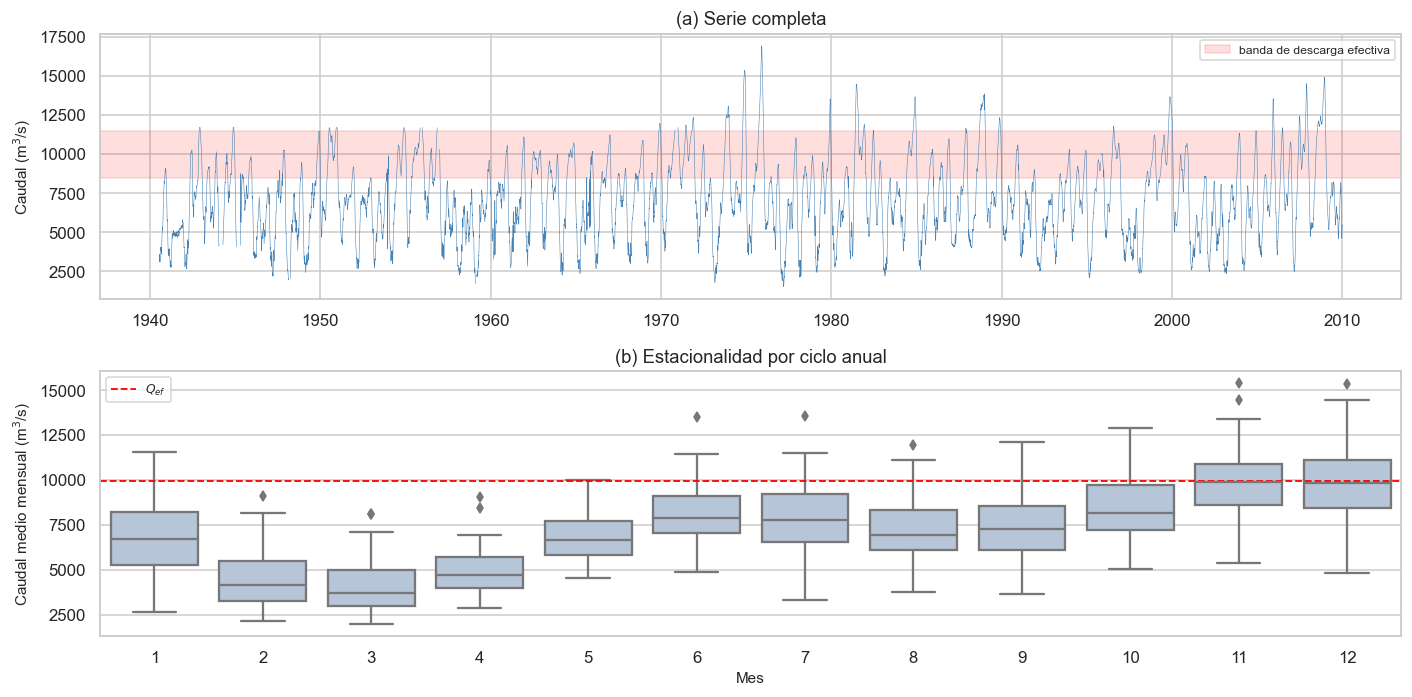

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6.5))

ax[0].plot(train.fecha, train[ESTACION_OBJETIVO], lw=.35, color="steelblue")
ax[0].axhspan(*LIM, color="red", alpha=.13, label="banda de descarga efectiva")
ax[0].set(ylabel="Caudal (m$^3$/s)", title="(a) Serie completa")
ax[0].legend(fontsize=8)

mensual = train.set_index("fecha")[ESTACION_OBJETIVO].resample("MS").mean()
sns.boxplot(x=mensual.index.month, y=mensual.values, ax=ax[1], color="lightsteelblue")
ax[1].axhline(Q_EF, color="red", ls="--", lw=1.2, label="$Q_{ef}$")
ax[1].set(xlabel="Mes", ylabel="Caudal medio mensual (m$^3$/s)",
          title="(b) Estacionalidad por ciclo anual")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURAS / "serie_estacionalidad.png", dpi=150)
plt.show()

C:\Users\Qclem\AppData\Local\Temp\ipykernel_19136\703876311.py:9: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


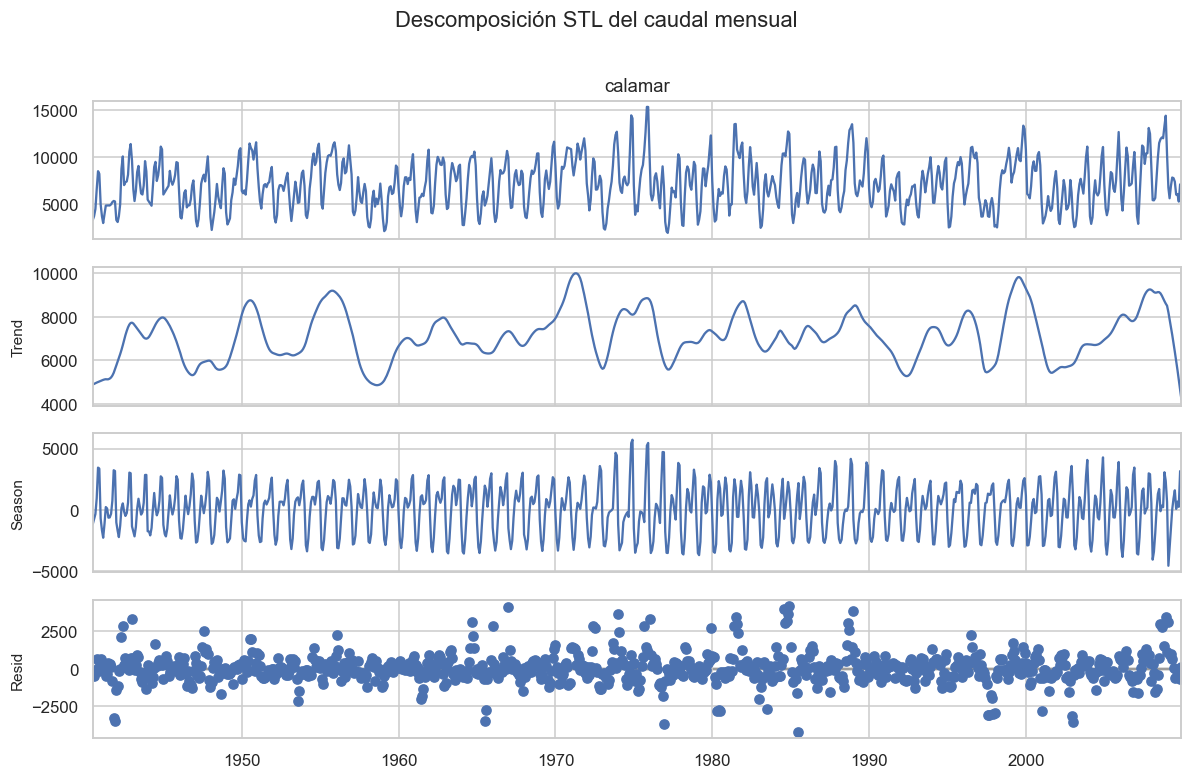

Tendencia 20.4% | Estacionalidad 62.9% | Residuo 16.7%


In [23]:
from statsmodels.tsa.seasonal import STL

serie = mensual.interpolate(limit=3).dropna()
stl = STL(serie, period=12, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(11, 7)
fig.suptitle("Descomposición STL del caudal mensual", y=1.01)
plt.tight_layout()
plt.savefig(FIGURAS / "stl.png", dpi=150)
plt.show()

total = np.var(stl.trend) + np.var(stl.seasonal) + np.var(stl.resid)
print(f"Tendencia {np.var(stl.trend)/total:.1%} | "
      f"Estacionalidad {np.var(stl.seasonal)/total:.1%} | "
      f"Residuo {np.var(stl.resid)/total:.1%}")

C:\Users\Qclem\AppData\Local\Temp\ipykernel_19136\1930425425.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  p_kpss = kpss(sd, regression="c", nlags="auto")[1]


ADF   H0: no estacionaria   p = 0.0000
KPSS  H0: sí estacionaria   p = 0.1000
Conclusión: la serie es estacionaria en nivel


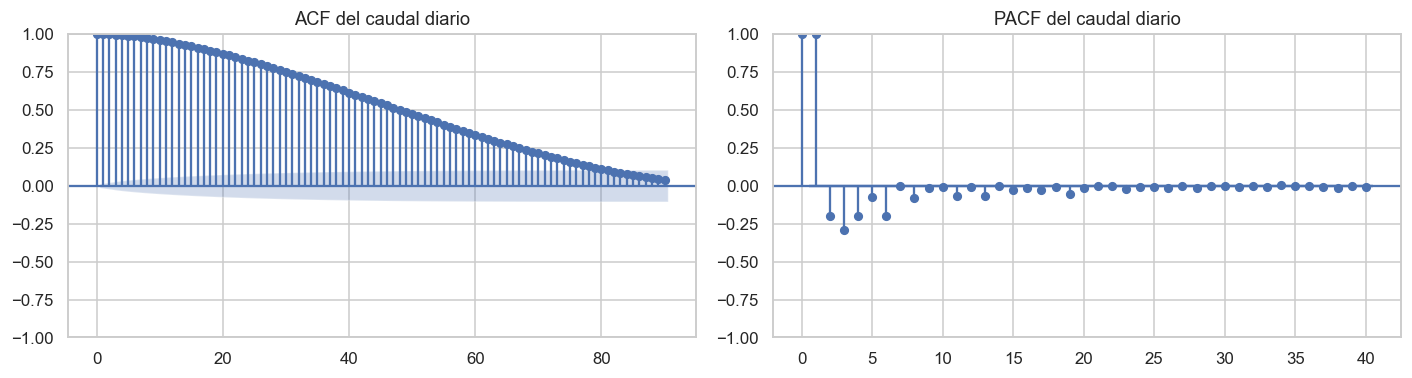


ACF: lag1 = 0.9987 | lag7 = 0.9769 | lag15 = 0.9180 | lag30 = 0.7491


In [24]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sd = train[ESTACION_OBJETIVO].dropna()
p_adf = adfuller(sd, autolag="AIC")[1]
p_kpss = kpss(sd, regression="c", nlags="auto")[1]

# Las dos pruebas tienen hipotesis nulas opuestas
print(f"ADF   H0: no estacionaria   p = {p_adf:.4f}")
print(f"KPSS  H0: sí estacionaria   p = {p_kpss:.4f}")
print("Conclusión:", "la serie es estacionaria en nivel" if p_adf < .05 and p_kpss >= .05
      else "las pruebas discrepan, interpretar con cautela")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
plot_acf(sd, lags=90, ax=ax[0])
ax[0].set_title("ACF del caudal diario")
plot_pacf(sd, lags=40, ax=ax[1], method="ywm")
ax[1].set_title("PACF del caudal diario")
plt.tight_layout()
plt.savefig(FIGURAS / "acf_pacf.png", dpi=150)
plt.show()

ac = acf(sd.values, nlags=60, fft=True)
print(f"\nACF: lag1 = {ac[1]:.4f} | lag7 = {ac[7]:.4f} | lag15 = {ac[15]:.4f} | lag30 = {ac[30]:.4f}")

In [25]:
# Tiempo de transito: rezago que maximiza la correlacion con la estacion objetivo
TRANSITOS, curvas = {}, {}
filas = []
for e in ESTACIONES:
    if e == ESTACION_OBJETIVO:
        continue
    r = [(k, train[e].shift(k).corr(train[ESTACION_OBJETIVO])) for k in range(31)]
    t = pd.DataFrame(r, columns=["rezago", "correlacion"])
    k_opt = int(t.loc[t.correlacion.idxmax(), "rezago"])
    TRANSITOS[e] = k_opt
    curvas[e] = t
    filas.append({"estacion": e, "transito_dias": k_opt,
                  "r_con_desfase": t.correlacion.max(),
                  "r_sin_desfase": t.loc[0, "correlacion"],
                  "ganancia": t.correlacion.max() - t.loc[0, "correlacion"]})

pd.DataFrame(filas).sort_values("transito_dias", ascending=False).round(4)

,estacion,transito_dias,r_con_desfase,r_sin_desfase,ganancia
3,pto_salgar,21,0.4340,0.3240,0.1101
0,arrancaplumas,20,0.4665,0.3595,0.1070
5,tres_cruces,16,0.7993,0.7229,0.0764
2,el_banco,12,0.8999,0.8503,0.0496
4,san_roque,10,0.9165,0.8780,0.0385
1,coyongal,7,0.9410,0.9199,0.0212


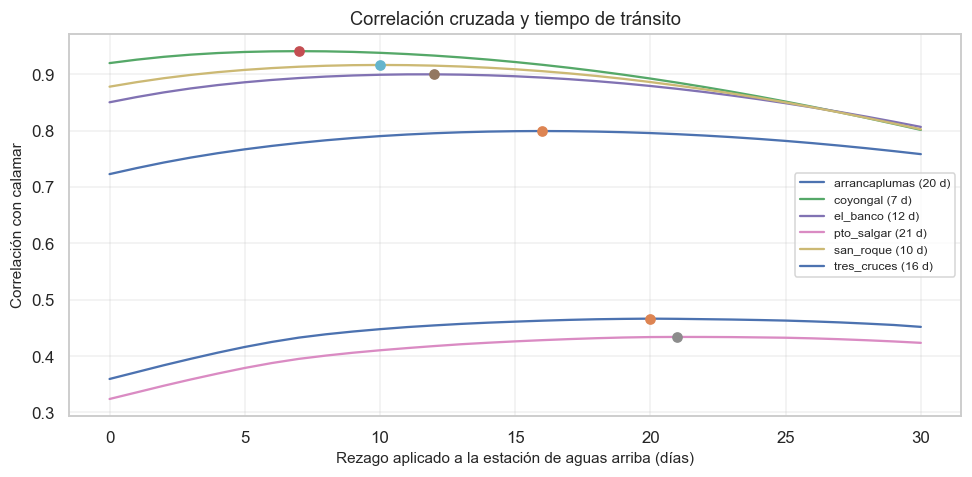

In [26]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for e, t in curvas.items():
    ax.plot(t.rezago, t.correlacion, lw=1.5, label=f"{e} ({TRANSITOS[e]} d)")
    ax.plot(TRANSITOS[e], t.correlacion.max(), "o", ms=6)

ax.set(xlabel="Rezago aplicado a la estación de aguas arriba (días)",
       ylabel=f"Correlación con {ESTACION_OBJETIVO}",
       title="Correlación cruzada y tiempo de tránsito")
ax.legend(fontsize=8)
ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIGURAS / "transito.png", dpi=150)
plt.show()

In [27]:
# Los rezagos se estimaron sin usar informacion geografica.
# Contrastarlos con la ubicacion real es una verificacion externa.
ubic = pd.read_csv(DATOS_CRUDOS.parent / "UBICACION_ESTACIONES_DESCARGADAS_IDEAM.csv",
                   sep=";", encoding="utf-8-sig")
ubic.columns = ["estacion", "codigo", "departamento", "municipio", "lat", "lon", "altitud"]

MAPA = {"ARRANCAPLUMAS - AUT": "arrancaplumas", "PUERTO SALGAR - AUT": "pto_salgar",
        "TRES CRUCES": "tres_cruces", "COYONGAL": "coyongal", "EL BANCO - AUT": "el_banco",
        "SAN ROQUE": "san_roque", "CALAMAR": "calamar"}
ubic["clave"] = ubic.estacion.map(MAPA)
ubic["transito"] = ubic.clave.map({**TRANSITOS, ESTACION_OBJETIVO: 0})

g = ubic.dropna(subset=["transito"]).sort_values("transito", ascending=False)
print(g[["estacion", "municipio", "altitud", "lat", "transito"]].to_string(index=False))
print()
for col, nom in [("altitud", "altitud"), ("lat", "latitud")]:
    r, p = st.pearsonr(g[col], g.transito)
    rs, _ = st.spearmanr(g[col], g.transito)
    print(f"tránsito vs {nom:8}  Pearson r = {r:+.4f} (p = {p:.4f})   Spearman = {rs:+.4f}")

           estacion     municipio  altitud       lat  transito
PUERTO SALGAR - AUT Puerto Salgar      168  5.469667        21
ARRANCAPLUMAS - AUT       Guaduas      222  5.202417        20
        TRES CRUCES          Achí       31  8.703083        16
     EL BANCO - AUT      El Banco       29  8.992528        12
          SAN ROQUE      El Banco       24  9.071622        10
           COYONGAL      Magangué       20  8.915130         7
            CALAMAR       Calamar        8 10.244042         0

tránsito vs altitud   Pearson r = +0.7865 (p = 0.0359)   Spearman = +0.9643
tránsito vs latitud   Pearson r = -0.8758 (p = 0.0098)   Spearman = -0.8571


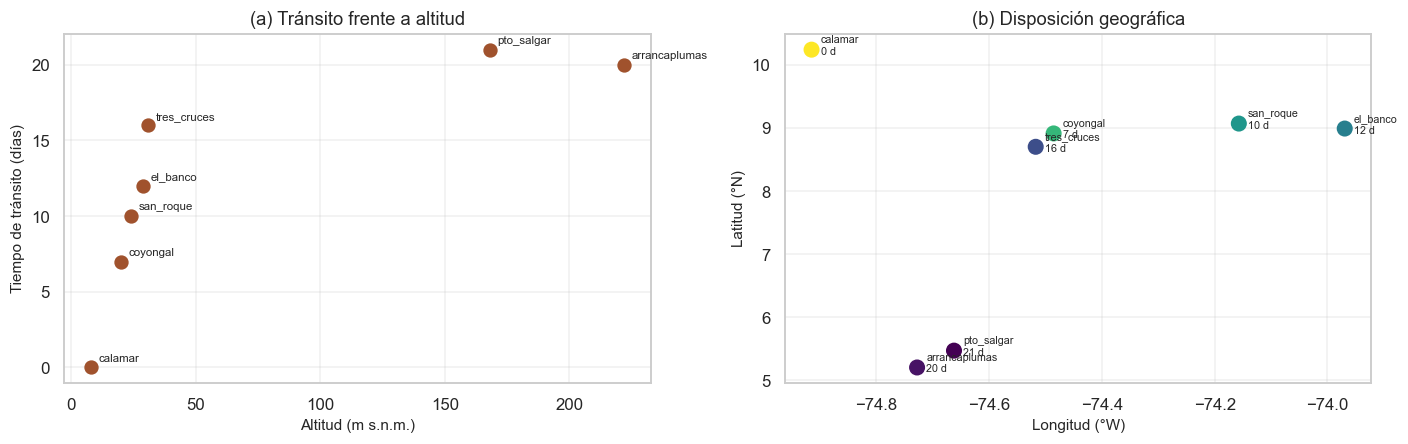

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

ax[0].scatter(g.altitud, g.transito, s=70, color="sienna", zorder=3)
for _, r in g.iterrows():
    ax[0].annotate(r.clave, (r.altitud, r.transito), fontsize=7.5,
                   xytext=(5, 4), textcoords="offset points")
ax[0].set(xlabel="Altitud (m s.n.m.)", ylabel="Tiempo de tránsito (días)",
          title="(a) Tránsito frente a altitud")
ax[0].grid(alpha=.3)

ax[1].scatter(g.lon, g.lat, s=90, c=g.transito, cmap="viridis_r", zorder=3)
for _, r in g.iterrows():
    ax[1].annotate(f"{r.clave}\n{int(r.transito)} d", (r.lon, r.lat), fontsize=7,
                   xytext=(6, -3), textcoords="offset points")
ax[1].set(xlabel="Longitud (°W)", ylabel="Latitud (°N)",
          title="(b) Disposición geográfica")
ax[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(FIGURAS / "validacion_geografica.png", dpi=150)
plt.show()

In [29]:
# Deriva entre decadas
d_ = train.copy()
d_["decada"] = d_.fecha.dt.year // 10 * 10
decadas = sorted(d_.decada.unique())
base = decadas[0]

filas = []
for dd in decadas[1:]:
    a_ = d_.loc[d_.decada == base, ESTACION_OBJETIVO].dropna()
    b_ = d_.loc[d_.decada == dd, ESTACION_OBJETIVO].dropna()
    if len(b_) < 300:
        continue
    ks, pv = st.ks_2samp(a_, b_)
    filas.append({"decada": dd, "n": len(b_), "media": b_.mean(), "KS": ks, "p_valor": pv})

print("Prueba de Kolmogorov-Smirnov frente a la primera década:")
print(pd.DataFrame(filas).round(4).to_string(index=False))
print()
dy = df[df.fecha < corte].dropna(subset=["y"]).copy()
dy["decada"] = dy.fecha.dt.year // 10 * 10
print("Prevalencia del objetivo por década:")
print(dy.groupby("decada").y.agg(["mean", "size"]).round(4).to_string())

Prueba de Kolmogorov-Smirnov frente a la primera década:
 decada    n     media     KS  p_valor
   1950 3495 6937.8990 0.1068      0.0
   1960 3653 7117.7495 0.1284      0.0
   1970 3591 7714.4414 0.1793      0.0
   1980 3653 7596.0619 0.1521      0.0
   1990 3637 7005.4399 0.0890      0.0
   2000 3650 7318.3740 0.1311      0.0

Prevalencia del objetivo por década:
          mean  size
decada              
1940    0.1951  3449
1950    0.2360  3652
1960    0.3263  3653
1970    0.2850  3652
1980    0.2527  3653
1990    0.2741  3652
2000    0.2242  3653


La estacionalidad por ciclo confirma el régimen bimodal característico del Magdalena, con
mínimo en febrero y marzo, máximo principal en noviembre y diciembre, y máximo secundario a
mitad de año. El patrón responde al doble paso de la Zona de Convergencia Intertropical
sobre la cuenca, por lo que el modelo incorpora componentes cíclicos anual y semianual.

La descomposición STL muestra que la estacionalidad domina frente a la tendencia, de modo
que el sistema está gobernado por el ciclo climático anual antes que por cambios seculares.

Las pruebas ADF y KPSS se leen conjuntamente por tener hipótesis nulas opuestas, y su
resultado respalda tratar la serie en niveles, sin diferenciación.

La función de autocorrelación decae con lentitud, y su valor sigue siendo sustancial a
quince y treinta días. De ahí que el tamaño efectivo de muestra resulte muy inferior al
número de filas, y que una partición aleatoria produjera una estimación optimista del
desempeño. La partición cronológica con intervalo de separación de treinta días atiende
ambos problemas.

La correlación cruzada recupera un gradiente coherente con la geografía: el rezago óptimo
crece con la distancia al mar y la correlación aumenta al aplicar el desfase. Dado que el
procedimiento no incorporó coordenadas ni altitudes, su concordancia con la ubicación real
de las estaciones constituye una verificación externa del resultado y respalda el uso de
esos rezagos como predictores. Arrancaplumas y Puerto Salgar invierten el orden estricto,
con tránsitos de veinte y veintiún días pese a diferir en altitud, circunstancia esperable
porque ambas se sitúan en el mismo tramo del alto Magdalena y su correlación con Calamar es
la más baja del conjunto.

La evaluación de deriva entre décadas refuerza la conveniencia de evaluar sobre un periodo
futuro en lugar de una muestra aleatoria.

## 3.7 Componentes espacial y espacio-temporal

La unidad de observación es el día en la estación Calamar. Las coordenadas de las siete
estaciones cumplen una función identificadora, puesto que cada estación ocupa una columna
fija del conjunto de datos y el muestreo carece de dimensión espacial continua.

Las técnicas propias del análisis espacial carecen por tanto de aplicación en este diseño.
El índice de Moran global, igual que los indicadores locales del tipo LISA o los
concentradores de Getis-Ord, parte de una muestra de unidades distribuidas sobre un
territorio, y con siete estaciones alineadas a lo largo de un único cauce el estadístico no
alcanza la potencia necesaria para producir un resultado interpretable. El semivariograma
presupone un campo continuo muestreado en el plano, mientras que la variación que aquí
interesa se produce a lo largo de una sola dimensión. La partición por bloques espaciales
responde a un objetivo diferente del de este trabajo, que predice en el futuro sobre una
estación fija, por lo que la partición empleada es cronológica.

La dependencia espacial de este sistema es la posición longitudinal de cada estación sobre
el cauce, y se trató con las herramientas adecuadas a esa geometría: la correlación cruzada
con rezagos de la sección 3.6, el análisis de multicolinealidad de la sección 3.3 y el
análisis de componentes principales de la sección 3.4.

## 3.8 Preprocesamiento

Todo el preprocesamiento se implementa dentro de un `Pipeline` y se ajusta únicamente con
el conjunto de entrenamiento.

| Decisión | Hallazgo que la motiva |
|---|---|
| No transformar el caudal mediante logaritmo ni Box-Cox | La asimetría en Calamar ronda 0,3 (3.2), de modo que la distribución ya es casi simétrica porque la cuenca baja amortigua los picos |
| No recortar valores extremos por rango intercuartílico | Según se argumenta en 2.6.3, esos extremos corresponden a crecidas plausibles y la validación física no detecta saltos anómalos |
| Imputar por mediana dentro del `Pipeline` | El mecanismo identificado en 2.6.1 es MAR, dado que la ausencia depende de la fecha de instalación de cada estación |
| Aplicar escalado estándar | Las escalas difieren entre estaciones en un orden de magnitud, de 500 a 7.200 m³/s (3.2) |
| Rezagar cada estación por su tiempo de tránsito | La correlación cruzada de 3.6 estima ese retardo de forma empírica para cada punto del cauce |
| Incluir componentes cíclicos anual y semianual | El régimen bimodal confirmado en 3.6 requiere dos armónicos para describirse |
| Añadir la variable $\lvert Q_t - Q_{ef}\rvert$ | El objetivo es una banda de caudales, que una frontera lineal no logra representar (capítulo 4) |
| Excluir Arrancaplumas de los predictores | Su registro termina en 2014 y cubre apenas el 28,6 % del periodo de prueba (2.6.1) |

In [30]:
def construir_features(d):
    """Predictores. Todos usan informacion hasta t; el objetivo esta en t+h."""
    x = d.sort_values("fecha").copy()
    o = ESTACION_OBJETIVO

    for k in (1, 2, 3, 5, 7, 10, 15, 30, 60):
        x[f"{o}_lag{k}"] = x[o].shift(k)

    for w in (7, 30, 90, 365):
        base = x[o].shift(1)          # shift(1) excluye el dia actual
        x[f"{o}_media{w}"] = base.rolling(w, min_periods=max(2, w//3)).mean()
        x[f"{o}_desv{w}"] = base.rolling(w, min_periods=max(2, w//3)).std()

    x[f"{o}_d1"] = x[o].diff(1)
    x[f"{o}_d7"] = x[o].diff(7)

    # Cada estacion entra con su tiempo de transito
    for e in PREDICTORAS:
        k = TRANSITOS.get(e, 0)
        x[f"{e}_t{k}"] = x[e].shift(k)
        x[f"{e}_d3"] = x[e].shift(k).diff(3)
        x[f"{e}_rel"] = x[e].shift(k) / x[e].shift(1).rolling(365, min_periods=120).mean()

    # Distancia a Q_ef: convierte la banda en un problema monotono
    x["dist_qef"] = (x[o] - Q_EF).abs()
    x["dist_qef_rel"] = x["dist_qef"] / Q_EF
    x[f"{o}_cuad"] = x[o] ** 2
    for k in (7, 15):
        x[f"dist_qef_lag{k}"] = (x[f"{o}_lag{k}"] - Q_EF).abs()

    # Regimen bimodal: primer y segundo armonico
    doy = x.fecha.dt.dayofyear
    x["sen_anual"] = np.sin(2 * np.pi * doy / 365.25)
    x["cos_anual"] = np.cos(2 * np.pi * doy / 365.25)
    x["sen_semi"] = np.sin(4 * np.pi * doy / 365.25)
    x["cos_semi"] = np.cos(4 * np.pi * doy / 365.25)
    return x

dfx = construir_features(df)

BASE_COLS = ([c for c in dfx.columns if c.startswith(f"{ESTACION_OBJETIVO}_")
              and not c.endswith("_cuad")]
             + [c for e in PREDICTORAS for c in dfx.columns if c.startswith(e + "_")]
             + ["sen_anual", "cos_anual", "sen_semi", "cos_semi"])
DOM_COLS = ["dist_qef", "dist_qef_rel", f"{ESTACION_OBJETIVO}_cuad",
            "dist_qef_lag7", "dist_qef_lag15"]
TODAS = BASE_COLS + DOM_COLS

print(f"Predictores: {len(TODAS)}")
print(f"  derivados del caudal objetivo y calendario: {len([c for c in BASE_COLS if not any(c.startswith(e) for e in PREDICTORAS)])}")
print(f"  derivados de estaciones aguas arriba:       {len([c for c in BASE_COLS if any(c.startswith(e) for e in PREDICTORAS)])}")
print(f"  de dominio:                                 {len(DOM_COLS)}")

Predictores: 43
  derivados del caudal objetivo y calendario: 23
  derivados de estaciones aguas arriba:       15
  de dominio:                                 5


In [31]:
# Verificacion anti-fuga sobre las variables construidas
dd = dfx[dfx.fecha < corte].dropna(subset=["y"])
filas = []
for c in TODAS:
    s = dd[[c, "y"]].dropna()
    if len(s) < 500:
        continue
    auc = roc_auc_score(s.y, s[c])
    filas.append({"variable": c, "AUC": max(auc, 1 - auc)})

vf = pd.DataFrame(filas).sort_values("AUC", ascending=False)
print("Las diez variables con mayor AUC univariado:")
print(vf.head(10).round(4).to_string(index=False))
print()
print("dist_qef tiene AUC alto por construcción: es la distancia al centro de la banda")
print("evaluada en t. Usa solo información de t y el objetivo está en t+15.")

Las diez variables con mayor AUC univariado:
      variable    AUC
  dist_qef_rel 0.9328
      dist_qef 0.9328
  calamar_cuad 0.8892
  calamar_lag1 0.8847
 dist_qef_lag7 0.8844
  calamar_lag2 0.8799
  calamar_lag3 0.8751
calamar_media7 0.8708
   coyongal_t7 0.8668
  calamar_lag5 0.8651

dist_qef tiene AUC alto por construcción: es la distancia al centro de la banda
evaluada en t. Usa solo información de t y el objetivo está en t+15.


In [32]:
# El capitulo 4 parte de estos archivos
dfx[["fecha", "y"] + TODAS + [ESTACION_OBJETIVO]].to_csv(DATOS_PROC / "features.csv", index=False)

parametros = {
    "Q_EF": float(Q_EF), "LIM": [float(LIM[0]), float(LIM[1])],
    "A_OF": float(A_OF), "B_OF": float(B_OF),
    "TRANSITOS": TRANSITOS, "BASE_COLS": BASE_COLS, "DOM_COLS": DOM_COLS,
}
with open(DATOS_PROC / "parametros.json", "w", encoding="utf-8") as f:
    json.dump(parametros, f, indent=2, ensure_ascii=False)

print(f"Guardados: features.csv ({len(dfx):,} filas) y parametros.json")

Guardados: features.csv (31,475 filas) y parametros.json
